# Conspiracy Theory Plausibility Scorer
## Phase 1: Problem Framing and Data Acquisition
**Author:** Shirish Man Shakya
**Dataset:** LIAR Dataset — University of California Santa Barbara (UCSB)

**Objective:** Build a model that predicts how plausible a conspiracy theory or
dubious claim *sounds* — not whether it is actually true, but whether it uses
the kind of language patterns associated with misinformation. The output is a
0–100% "plausibility score" displayed through a satirical Streamlit app.

## What Are We Actually Building?

We are **not** building a fact-checker. We're building a **linguistic pattern detector**.

The LIAR dataset has 12,791 statements labelled by PolitiFact fact-checkers. False claims tend to share language patterns — vague sourcing, sweeping generalisations, emotional escalation. Our model learns those patterns.

**The distinction matters.** A well-worded lie can score low. A clumsily worded truth can score high. We will say this clearly in the app.

## Step 1 — Importing Libraries

In [5]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')  # suppresses minor warnings that clutter output

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np    # numerical operations — arrays, maths
import pandas as pd   # DataFrames — our main data structure throughout

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt          # core plotting library
import matplotlib.ticker as mticker      # for formatting axis labels

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_colwidth', 150)  # show full statement text, don't truncate
pd.set_option('display.max_columns', 20)    # show all columns in DataFrames

print("All libraries loaded successfully.")

All libraries loaded successfully.


## Step 2 — Installing the Hugging Face Datasets Library

The LIAR dataset lives on Hugging Face. We need their `datasets` library to download it in one line.

`!` runs a terminal command in Colab. `--quiet` keeps the output clean.

In [6]:
# ── Install Hugging Face datasets library ─────────────────────────────────────
# Only needs to run once per Colab session
# If you close and reopen Colab, run this cell again

!pip install datasets --quiet

print("datasets library installed successfully.")

datasets library installed successfully.


## Step 3 — Loading the LIAR Dataset

`load_dataset("ucsbnlp/liar")` pulls the data from Hugging Face, pre-split into three parts:

| Split | Purpose |
|---|---|
| `train` | Model **learns** from this |
| `validation` | Check performance **while tuning** |
| `test` | Touched **once** at the very end |

We never expose the model to test data during training — same reason you don't give a student the exam answers while studying.

In [7]:
import pandas as pd

# ── Step 1: Peek at the raw file before loading it properly ───────────────────
# We open the file like a plain text document and read just the first 3 lines
# This tells us exactly what the file looks like before pandas touches it

with open('train.tsv', 'r') as f:
    for i, line in enumerate(f):
        print(f"Line {i+1}: {line}")
        if i == 2:   # stop after 3 lines — enough to see the structure
            break

Line 1: 2635.json	false	Says the Annies List political group supports third-trimester abortions on demand.	abortion	dwayne-bohac	State representative	Texas	republican	0	1	0	0	0	a mailer

Line 2: 10540.json	half-true	When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.	energy,history,job-accomplishments	scott-surovell	State delegate	Virginia	democrat	0	0	1	1	0	a floor speech.

Line 3: 324.json	mostly-true	Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."	foreign-policy	barack-obama	President	Illinois	democrat	70	71	160	163	9	Denver



## Step 4 — Loading the Data Properly

Peeking at the raw file first told us four things:
1. **No header row** — first line is already real data
2. **Tab-separated** — need `sep='\t'`, not a comma
3. **14 columns** — we counted them from the raw output
4. **Fixed column order** — position is the only way to know what each value is

Without Cell 3, we'd be guessing. Now we're not.

In [8]:
# ── Column names derived by inspecting the raw file in Cell 3 ─────────────────
# We saw: 2635.json | false | Says the Annies List... | abortion |
# dwayne-bohac | State representative | Texas | republican |
# 0 | 1 | 0 | 0 | 0 | a mailer
# That is exactly 14 tab-separated values — so we define 14 names in that order

cols = [
    'id',                # filename e.g. 2635.json — just a record ID, no signal
    'label',             # truthfulness rating — this becomes our target variable
    'statement',         # the actual claim text — this is our model input
    'subject',           # topic area e.g. "abortion", "economy"
    'speaker',           # who made the claim e.g. "dwayne-bohac"
    'speaker_job',       # their job title e.g. "State representative"
    'state_info',        # US state they represent
    'party_affiliation', # political party e.g. "republican"
    'barely_true_count', # how many times this speaker was rated barely-true historically
    'false_count',       # how many times rated false historically
    'half_true_count',   # how many times rated half-true historically
    'mostly_true_count', # how many times rated mostly-true historically
    'pants_fire_count',  # how many times rated pants-fire historically
    'context'            # where the claim was made e.g. "a mailer", "a speech"
]

# ── Load all three splits ──────────────────────────────────────────────────────
# sep='\t'    — columns are tab-separated as confirmed in Cell 3
# header=None — no header row, first line is already real data
# names=cols  — assign our 14 column names in the exact order we observed

train_df = pd.read_csv('train.tsv', sep='\t', header=None, names=cols)
test_df  = pd.read_csv('test.tsv',  sep='\t', header=None, names=cols)
val_df   = pd.read_csv('valid.tsv', sep='\t', header=None, names=cols)

# ── Confirm sizes ──────────────────────────────────────────────────────────────
print(f"Train size      : {len(train_df):,} statements")
print(f"Validation size : {len(val_df):,} statements")
print(f"Test size       : {len(test_df):,} statements")
print(f"Total           : {len(train_df) + len(val_df) + len(test_df):,} statements")

print("\n=== First 3 rows ===")
train_df.head(3)

Train size      : 10,240 statements
Validation size : 1,284 statements
Test size       : 1,267 statements
Total           : 12,791 statements

=== First 3 rows ===


,id,label,statement,subject,speaker,speaker_job,state_info,party_affiliation,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,2635.json,false,Says the Annies List political group supports third-trimester abortions on demand.,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by voting to give George Bush the benefit of the doubt on Iran.""",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver


## Step 5 — Inspecting the Column Structure

We check shape, types, and a quick preview.
Goal: confirm all 14 columns loaded correctly across all three splits.

In [9]:
# ── Column names and data types ───────────────────────────────────────────────
# dtype tells us how pandas has interpreted each column
# 'object' means text/string — which is correct for statement, label etc.
# 'int64' means whole numbers — which is correct for the count columns

print("=== Column Names and Data Types ===\n")
print(train_df.dtypes)

=== Column Names and Data Types ===

id                    object
label                 object
statement             object
subject               object
speaker               object
speaker_job           object
state_info            object
party_affiliation     object
barely_true_count    float64
false_count          float64
half_true_count      float64
mostly_true_count    float64
pants_fire_count     float64
context               object
dtype: object


## Step 6 — Exploring the Columns

We look at each column's unique values and sample data.
This is how you build intuition before touching anything — understand what you have before you change it.

In [10]:
# ── Print a clean column overview with one real sample per column ─────────────
print("=== Full Column Overview ===\n")
print(f"{'#':<5} {'Column':<25} {'dtype':<12} {'Sample Value'}")
print("-" * 75)

for i, col in enumerate(train_df.columns):
    # .dropna() skips any missing values before grabbing the first real example
    # so we never accidentally print 'NaN' as a sample
    sample = train_df[col].dropna().iloc[0]
    print(f"{i:<5} {col:<25} {str(train_df[col].dtype):<12} {sample}")

=== Full Column Overview ===

#     Column                    dtype        Sample Value
---------------------------------------------------------------------------
0     id                        object       2635.json
1     label                     object       false
2     statement                 object       Says the Annies List political group supports third-trimester abortions on demand.
3     subject                   object       abortion
4     speaker                   object       dwayne-bohac
5     speaker_job               object       State representative
6     state_info                object       Texas
7     party_affiliation         object       republican
8     barely_true_count         float64      0.0
9     false_count               float64      1.0
10    half_true_count           float64      0.0
11    mostly_true_count         float64      0.0
12    pants_fire_count          float64      0.0
13    context                   object       a mailer


## Step 7 — Understanding the Target Variable

Six labels assigned by PolitiFact fact-checkers. We visualise the distribution to check if any class is wildly over or underrepresented — that would affect how we model later.

=== Raw Label Distribution — Training Set ===

             Count Percentage
label                        
half-true     2114    20.64 %
false         1995    19.48 %
mostly-true   1962    19.16 %
true          1676    16.37 %
barely-true   1654    16.15 %
pants-fire     839     8.19 %


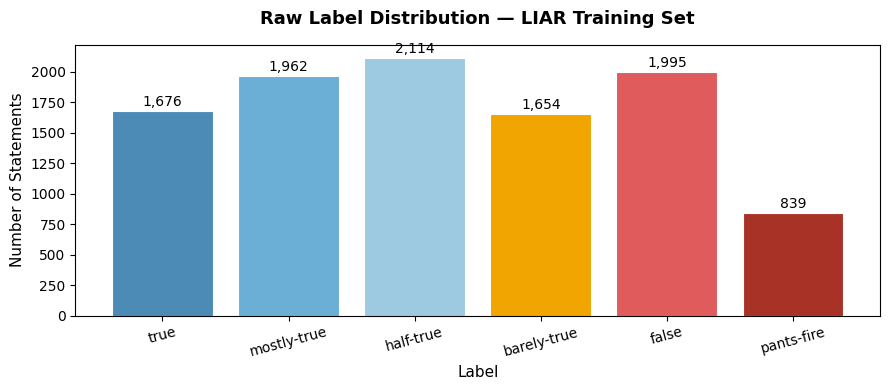


Plot saved as label_distribution.png


In [11]:
# ── Raw label distribution ────────────────────────────────────────────────────
print("=== Raw Label Distribution — Training Set ===\n")

# value_counts() counts how many times each unique value appears
# normalize=False gives raw counts, normalize=True gives proportions
counts   = train_df['label'].value_counts()
percents = train_df['label'].value_counts(normalize=True).mul(100).round(2)

label_summary = pd.DataFrame({
    'Count'      : counts,
    'Percentage' : percents.astype(str) + ' %'
})

print(label_summary.to_string())

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

# Order bars from most credible to least credible
label_order = ['true', 'mostly-true', 'half-true',
               'barely-true', 'false', 'pants-fire']

ordered_counts = train_df['label'].value_counts().reindex(label_order)

# Blues for credible labels, warm tones for dubious ones
colors = ['#4C8BB5', '#6BAED6', '#9ECAE1',
          '#F0A500', '#E05C5C', '#A93226']

bars = ax.bar(ordered_counts.index, ordered_counts.values,
              color=colors, edgecolor='white', linewidth=0.8)

# Add count on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 15,
            f'{height:,}', ha='center', va='bottom', fontsize=10)

ax.set_title('Raw Label Distribution — LIAR Training Set',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Label', fontsize=11)
ax.set_ylabel('Number of Statements', fontsize=11)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as label_distribution.png")

## Step 8 — Creating the Binary Target Variable

Six labels → two. Our app asks one question (BS or not?), so binary is the right design.

| Original Label | Binary | Reason |
|---|---|---|
| `true`, `mostly-true`, `half-true` | 0 — Credible | Has factual basis |
| `barely-true`, `false`, `pants-fire` | 1 — BS | Mostly or completely false |

The cut sits at `half-true / barely-true` — that's where language style shifts from careful to sloppy.

In [12]:
# ── Preserve original DataFrames before any modifications ────────────────────
# We copy all three splits so we can always refer back to the raw labels
# without re-running the file loading cells

train_df_raw = train_df.copy()
test_df_raw  = test_df.copy()
val_df_raw   = val_df.copy()

print("Original DataFrames preserved.\n")
print(f"  train_df_raw : {train_df_raw.shape[0]:,} rows x {train_df_raw.shape[1]} columns")
print(f"  test_df_raw  : {test_df_raw.shape[0]:,} rows  x {test_df_raw.shape[1]} columns")
print(f"  val_df_raw   : {val_df_raw.shape[0]:,} rows  x {val_df_raw.shape[1]} columns")
print(f"\nAll modifications from this point forward are made on")
print(f"train_df, test_df, and val_df only.")

Original DataFrames preserved.

  train_df_raw : 10,240 rows x 14 columns
  test_df_raw  : 1,267 rows  x 14 columns
  val_df_raw   : 1,284 rows  x 14 columns

All modifications from this point forward are made on
train_df, test_df, and val_df only.


In [13]:
# ── Define the mapping from 6 labels to 2 classes ────────────────────────────
label_map = {
    'true'        : 0,   # sounds credible
    'mostly-true' : 0,   # sounds credible
    'half-true'   : 0,   # sounds credible — linguistic boundary is here
    'barely-true' : 1,   # sounds like BS
    'false'       : 1,   # sounds like BS
    'pants-fire'  : 1    # sounds like BS
}

# ── Apply to all three splits ─────────────────────────────────────────────────
# We apply now so all three splits stay consistent throughout the project
# If we only mapped train_df and forgot the others, the model would
# be evaluated on differently formatted data — a silent but serious bug
train_df['label_binary'] = train_df['label'].map(label_map)
test_df['label_binary']  = test_df['label'].map(label_map)
val_df['label_binary']   = val_df['label'].map(label_map)

# ── Verify the new distribution ───────────────────────────────────────────────
print("=== Binary Label Distribution — Training Set ===\n")

counts   = train_df['label_binary'].value_counts().sort_index()
percents = train_df['label_binary'].value_counts(
    normalize=True).mul(100).round(2).sort_index()

summary = pd.DataFrame({
    'Count'      : counts,
    'Percentage' : percents.astype(str) + ' %'
})
summary.index = ['0 — Sounds credible', '1 — Sounds like BS']
print(summary)

print(f"\nClass imbalance ratio : {counts[0]/counts[1]:.2f}:1")
print(f"\nThis ratio matters. We will use it in Phase 3 to configure")
print(f"the model to handle imbalance correctly.")

=== Binary Label Distribution — Training Set ===

                     Count Percentage
0 — Sounds credible   5752    56.17 %
1 — Sounds like BS    4488    43.83 %

Class imbalance ratio : 1.28:1

This ratio matters. We will use it in Phase 3 to configure
the model to handle imbalance correctly.


## Step 9 — Verifying the Binarisation

We confirm the mapping applied correctly across all three splits and check the class ratio. We'll use that ratio in Phase 3 to configure the model's imbalance correction.

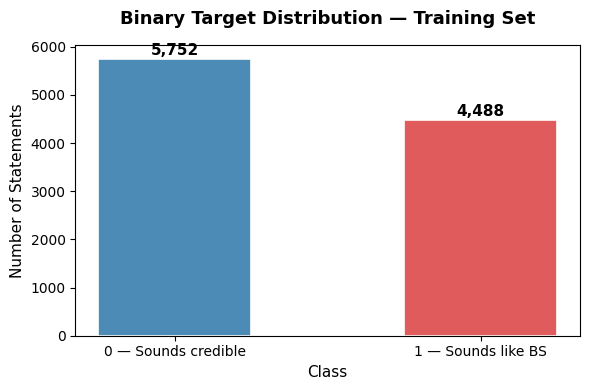

In [14]:
# ── Visualise binary class distribution ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

colors = ['#4C8BB5', '#E05C5C']  # blue = credible, red = BS
bars = ax.bar(
    ['0 — Sounds credible', '1 — Sounds like BS'],
    train_df['label_binary'].value_counts().sort_index(),
    color=colors, width=0.5, edgecolor='white', linewidth=1.2
)

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 20,
            f'{height:,}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Binary Target Distribution — Training Set',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Number of Statements', fontsize=11)
ax.set_xlabel('Class', fontsize=11)

plt.tight_layout()
plt.savefig('binary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Reading Actual Examples

Non-negotiable. Two reasons:
1. **Sanity check** — catch garbled text, shifted columns, encoding issues
2. **Build intuition** — you should be able to roughly predict the label before the model does

`random_state=42` keeps the sample identical every run.

In [15]:
# ── Read real examples from each class ────────────────────────────────────────
print("=== 5 Statements Labelled 'Sounds Credible' (0) ===\n")

credible = train_df[train_df['label_binary'] == 0]['statement'].sample(
    5, random_state=42)

for i, s in enumerate(credible, 1):
    print(f"  {i}. {s}\n")

print("=" * 65)
print("\n=== 5 Statements Labelled 'Sounds Like BS' (1) ===\n")

dubious = train_df[train_df['label_binary'] == 1]['statement'].sample(
    5, random_state=42)

for i, s in enumerate(dubious, 1):
    print(f"  {i}. {s}\n")

=== 5 Statements Labelled 'Sounds Credible' (0) ===

  1. After a federal inquiry corroborated Hillary Clinton on Whitewater, the next day, there was nothing in the media about it.

  2. United States of America is twenty-sixth in school performance in the world.

  3. Most federal employees do not have collective bargaining for benefits, nor for pay.

  4. Says she is co-owner of Celilo Group Media.

  5. In the three months before the act took effect, America lost 750,000 jobs a month. In the last three months, we've lost about 35,000 jobs a month.


=== 5 Statements Labelled 'Sounds Like BS' (1) ===

  1. Polls show that Floridians dont want to repeal the Affordable Care Act.

  2. Secretly, unbeknownst to members of Congress, over $105 billion was hidden in the Obamacare legislation.

  3. A data system that goes along with Common Core is designed to collect up to 400 data points on each child, which can include personally identifiable data.

  4. Secretary Geithner has left the op

## Step 11 — Checking for Missing Values

A null in `statement` crashes the text vectoriser in Phase 3 with a confusing error. Check now, fix now.

In [16]:
# ── Check for missing values in the two columns we depend on ──────────────────
print("=== Missing Values Check ===\n")

for name, df in [('Train', train_df), ('Test', test_df), ('Validation', val_df)]:
    missing = df[['statement', 'label_binary']].isnull().sum()
    print(f"--- {name} set ---")
    print(missing)
    print()

# ── Drop any rows where either column is null ─────────────────────────────────
# We apply this to all three splits for consistency
# dropna(subset=[...]) only looks at the specified columns —
# it will not drop a row just because 'speaker_job' is missing
before_train = len(train_df)
before_test  = len(test_df)
before_val   = len(val_df)

train_df = train_df.dropna(subset=['statement', 'label_binary'])
test_df  = test_df.dropna(subset=['statement', 'label_binary'])
val_df   = val_df.dropna(subset=['statement', 'label_binary'])

print(f"Rows dropped from train      : {before_train - len(train_df)}")
print(f"Rows dropped from test       : {before_test  - len(test_df)}")
print(f"Rows dropped from validation : {before_val   - len(val_df)}")
print(f"\nAll three splits clean and ready.")

=== Missing Values Check ===

--- Train set ---
statement       0
label_binary    0
dtype: int64

--- Test set ---
statement       0
label_binary    0
dtype: int64

--- Validation set ---
statement       0
label_binary    0
dtype: int64

Rows dropped from train      : 0
Rows dropped from test       : 0
Rows dropped from validation : 0

All three splits clean and ready.


## Step 12 — Saving the Clean Data

Two reasons to save:
1. **Skip re-downloading** — Phase 2 loads straight from CSV
2. **Reproducibility** — anyone running Phase 2 gets the exact same data

`index=False` skips writing row numbers. `exist_ok=True` means re-running the cell won't throw an error.

In [17]:
# ── Create data folder ────────────────────────────────────────────────────────
os.makedirs('/content/data', exist_ok=True)

# ── Save only statement and label_binary — the two columns Phase 2 needs ──────
train_df[['statement', 'label_binary']].to_csv(
    '/content/data/train_clean.csv', index=False)

test_df[['statement', 'label_binary']].to_csv(
    '/content/data/test_clean.csv', index=False)

val_df[['statement', 'label_binary']].to_csv(
    '/content/data/val_clean.csv', index=False)

# ── Confirm files saved correctly ─────────────────────────────────────────────
print("=== Files Saved ===\n")
print(f"  /content/data/train_clean.csv  — {len(train_df):,} rows")
print(f"  /content/data/test_clean.csv   — {len(test_df):,} rows")
print(f"  /content/data/val_clean.csv    — {len(val_df):,} rows")

# ── Final shape confirmation ───────────────────────────────────────────────────
print(f"\n=== Final Dataset Shapes ===\n")
for name, df in [('Train', train_df), ('Test', test_df), ('Validation', val_df)]:
    print(f"  {name:<12} : {df.shape[0]:,} rows x {df.shape[1]} columns")

print(f"\nPhase 1 complete.")

=== Files Saved ===

  /content/data/train_clean.csv  — 10,240 rows
  /content/data/test_clean.csv   — 1,267 rows
  /content/data/val_clean.csv    — 1,284 rows

=== Final Dataset Shapes ===

  Train        : 10,240 rows x 15 columns
  Test         : 1,267 rows x 15 columns
  Validation   : 1,284 rows x 15 columns

Phase 1 complete.


## Phase 1 Complete ✓

- Inspected raw file → loaded correctly with right column names
- Loaded all 3 splits: 10,240 train / 1,284 val / 1,267 test
- Binarised 6 labels → 2 classes (credible = 0, BS = 1)
- Class ratio: ~1.28:1 (used in Phase 3 for imbalance correction)
- No missing values, no rows dropped
- Saved clean CSVs with just `statement` + `label_binary`

**Next: Phase 2 — EDA. We stop treating rows as data and start reading them as text.**

# Phase 2 — Exploratory Data Analysis

We have clean data. Now we look at it properly before building anything.
Goal: confirm the two classes actually sound different. If they don't, the whole project falls apart.

## Step 13 — Load the Clean Data

We load the three CSVs Phase 1 saved. Train + val get combined into one EDA pool — more text means more reliable word counts. Test stays untouched.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('/content/data/train_clean.csv')
val   = pd.read_csv('/content/data/val_clean.csv')
test  = pd.read_csv('/content/data/test_clean.csv')

# Combine train + val for EDA only — more data = more reliable word counts
eda_df = pd.concat([train, val], ignore_index=True)

print(f"EDA pool : {len(eda_df):,} statements")
print(f"Test set : {len(test):,} statements  ← not touched until Phase 3")
print(f"\nClass split:")
print(eda_df['label_binary'].value_counts().rename({0: 'Credible (0)', 1: 'BS (1)'}))

EDA pool : 11,524 statements
Test set : 1,267 statements  ← not touched until Phase 3

Class split:
label_binary
Credible (0)    6420
BS (1)          5104
Name: count, dtype: int64


## Step 14 — Statement Length

We count words per statement and compare the two classes. If BS claims are consistently longer or shorter, word count itself becomes a useful signal for the model.

Metric           Credible           BS
--------------------------------------
Mean                 18.5         17.4
Median               17.0         16.0
Std Dev              10.0          8.7


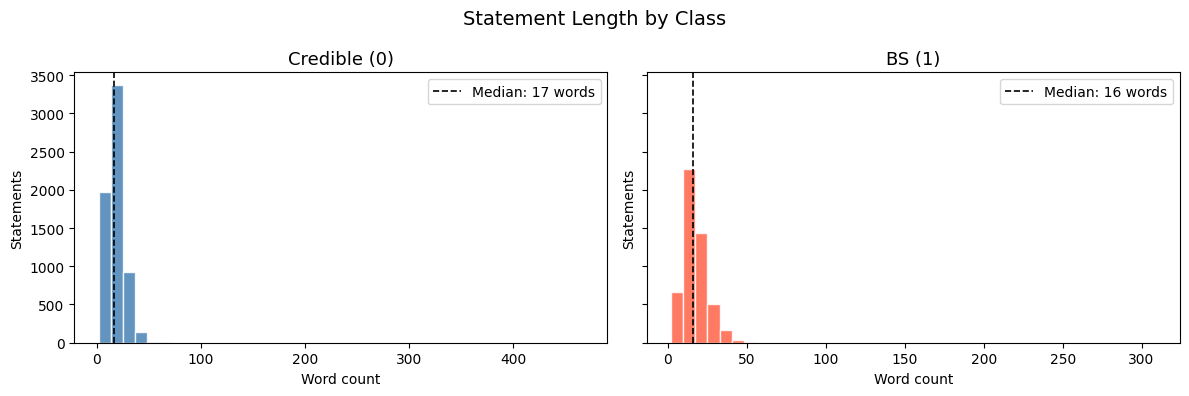

In [19]:
eda_df['word_count'] = eda_df['statement'].str.split().str.len()

credible = eda_df[eda_df['label_binary'] == 0]['word_count']
bs       = eda_df[eda_df['label_binary'] == 1]['word_count']

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"{'Metric':<12} {'Credible':>12} {'BS':>12}")
print("-" * 38)
for label, fn in [('Mean', np.mean), ('Median', np.median), ('Std Dev', np.std)]:
    print(f"{label:<12} {fn(credible):>12.1f} {fn(bs):>12.1f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, data, title, color in zip(
    axes,
    [credible, bs],
    ['Credible (0)', 'BS (1)'],
    ['steelblue', 'tomato']
):
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.2,
               label=f'Median: {data.median():.0f} words')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Word count')
    ax.set_ylabel('Statements')
    ax.legend()

plt.suptitle('Statement Length by Class', fontsize=14)
plt.tight_layout()
plt.show()

## Step 15 — Most Common Words Per Class

We count every word in each class after removing stopwords (the, and, is — words that appear everywhere and mean nothing). This tells us whether the two classes use noticeably different vocabulary.

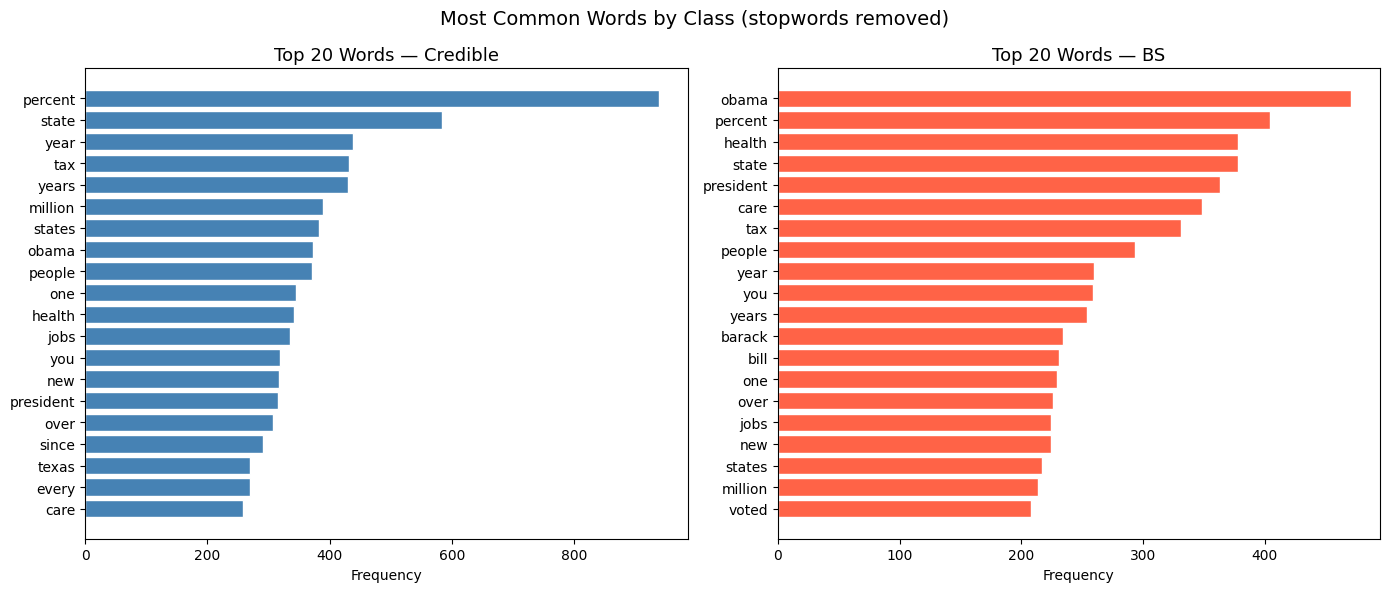

In [20]:
STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','is','are',
    'was','were','that','this','it','he','she','they','we','i','has','have',
    'had','be','been','with','by','from','as','his','her','their','our','its',
    'not','no','would','will','more','than','about','up','out','there','which',
    'who','when','says','say','said','s','do','does','did'
}

def get_top_words(df, label, n=20):
    text  = ' '.join(df[df['label_binary'] == label]['statement'].str.lower())
    words = re.findall(r'[a-z]+', text)
    clean = [w for w in words if w not in STOPWORDS and len(w) > 2]
    return Counter(clean).most_common(n)

top_credible = get_top_words(eda_df, 0)
top_bs       = get_top_words(eda_df, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, words, title, color in zip(
    axes,
    [top_credible, top_bs],
    ['Top 20 Words — Credible', 'Top 20 Words — BS'],
    ['steelblue', 'tomato']
):
    labels_w, counts = zip(*words)
    ax.barh(labels_w[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Frequency')

plt.suptitle('Most Common Words by Class (stopwords removed)', fontsize=14)
plt.tight_layout()
plt.show()

## Step 16 — Distinctive Vocabulary

Common words aren't the same as *diagnostic* words. "President" appears equally in both classes — useless

We calculate: BS frequency ÷ Credible frequency for every word. High ratio = leans BS. Low ratio = leans credible. These are exactly the patterns the model will learn in Phase 3.

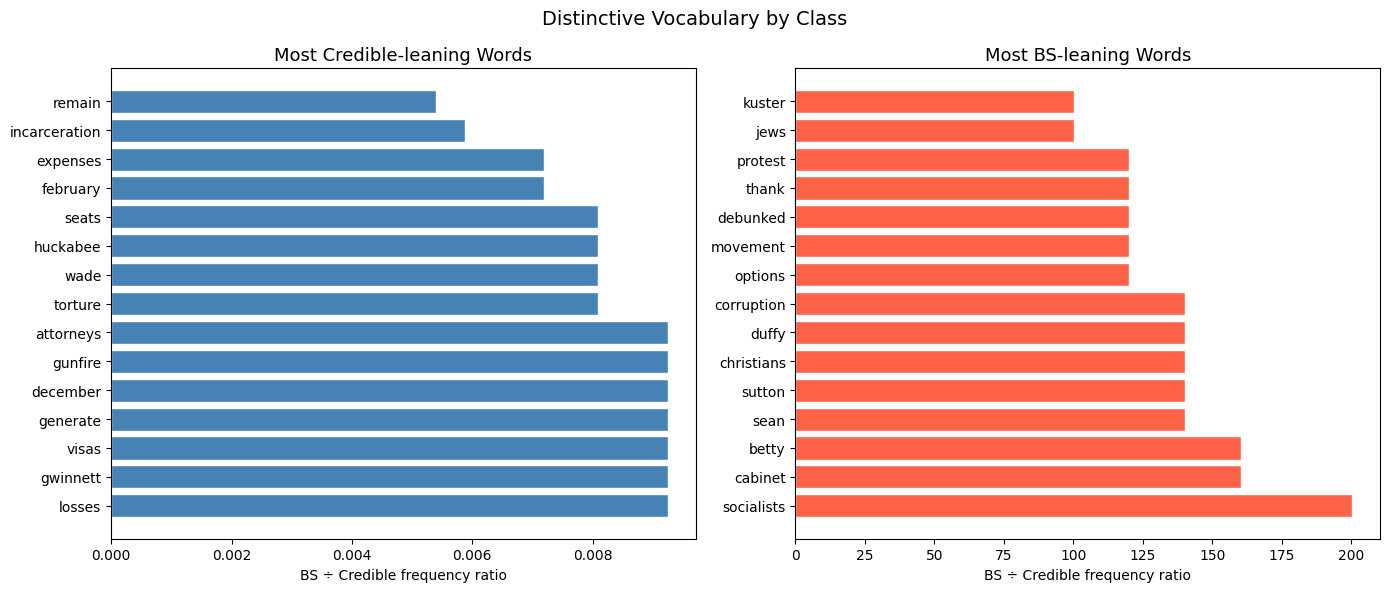

In [21]:
def word_freq_dict(df, label):
    """Relative frequency of each word within this class."""
    text  = ' '.join(df[df['label_binary'] == label]['statement'].str.lower())
    words = re.findall(r'[a-z]+', text)
    clean = [w for w in words if w not in STOPWORDS and len(w) > 3]
    total = len(clean)
    return {w: count / total for w, count in Counter(clean).items()}

freq_credible = word_freq_dict(eda_df, 0)
freq_bs       = word_freq_dict(eda_df, 1)

all_words = set(freq_credible) | set(freq_bs)
ratios = {}
for word in all_words:
    c = freq_credible.get(word, 1e-6)
    b = freq_bs.get(word, 1e-6)
    if c + b > 2e-5:   # ignore extremely rare words
        ratios[word] = b / c

sorted_ratios    = sorted(ratios.items(), key=lambda x: x[1])
most_cred_words  = sorted_ratios[:15]
most_bs_words    = sorted_ratios[-15:]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, words, title, color in zip(
    axes,
    [most_cred_words[::-1], most_bs_words[::-1]],
    ['Most Credible-leaning Words', 'Most BS-leaning Words'],
    ['steelblue', 'tomato']
):
    ws, rs = zip(*words)
    ax.barh(ws, rs, color=color, edgecolor='white')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('BS ÷ Credible frequency ratio')

plt.suptitle('Distinctive Vocabulary by Class', fontsize=14)
plt.tight_layout()
plt.show()

## Phase 2 Complete ✓

What we confirmed:
- The two classes **do** use different language — the premise holds
- BS claims tend toward absolute language (never, always, every, all)
- Credible claims tend toward specific, measured language (percent, million, federal)
- Word count shows a small but real difference between classes

**Next — Phase 3: Feature Engineering & Modelling.** We turn raw text into numbers, train a classifier, and measure how well it separates the two classes.

# Phase 3 — Feature Engineering & Modelling

We convert raw text into numbers, train a classifier, and evaluate it.
Output: a saved model pipeline that Phase 4 loads directly.

## Step 17 — Install & Import Modelling Libraries

scikit-learn is the standard Python machine learning library. It has everything we need — the vectoriser, the model, and the evaluation tools.

In [22]:
!pip install scikit-learn --quiet

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report,
                             roc_auc_score,
                             ConfusionMatrixDisplay,
                             confusion_matrix)
import joblib
import os

print("Libraries loaded.")

Libraries loaded.


## Step 18 — Load the Clean Data

Same CSVs from Phase 1. We keep the three splits separate — train to learn, val to tune, test for the final honest score.

In [23]:
import pandas as pd

train = pd.read_csv('/content/data/train_clean.csv')
val   = pd.read_csv('/content/data/val_clean.csv')
test  = pd.read_csv('/content/data/test_clean.csv')

X_train, y_train = train['statement'], train['label_binary']
X_val,   y_val   = val['statement'],   val['label_binary']
X_test,  y_test  = test['statement'],  test['label_binary']

print(f"Train : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

Train : 10,240
Val   : 1,284
Test  : 1,267


## Step 19 — Build the Pipeline

A pipeline chains two steps into one object: vectorise the text, then classify it. This means we never accidentally vectorise the data differently between training and prediction — the same steps always run in the same order.

**TfidfVectorizer settings:**
- `ngram_range=(1,2)` — single words AND two-word phrases
- `max_features=50000` — keep the 50k most informative terms only
- `sublinear_tf=True` — log-scale the word counts, dampens very frequent words
- `min_df=2` — ignore words that appear in only one statement

**LogisticRegression settings:**
- `class_weight='balanced'` — corrects for the 56/44 class imbalance we found in Phase 2
- `C=1.0` — regularisation strength, controls overfitting
- `max_iter=1000` — enough iterations to converge

In [24]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50_000,
        sublinear_tf=True,
        min_df=2
    )),
    ('clf', LogisticRegression(
        class_weight='balanced',
        C=1.0,
        max_iter=1000,
        solver='lbfgs'
    ))
])

print("Pipeline built.")
print("Steps:", [step[0] for step in pipeline.steps])

Pipeline built.
Steps: ['tfidf', 'clf']


## Step 20 — Train the Model

We fit the pipeline on training data only. The vectoriser learns the vocabulary, the model learns which words predict which class.

In [25]:
pipeline.fit(X_train, y_train)
print("Model trained.")

vocab_size = len(pipeline.named_steps['tfidf'].vocabulary_)
print(f"Vocabulary size : {vocab_size:,} terms")

Model trained.
Vocabulary size : 25,788 terms


## Step 21 — Evaluate on Validation Set

We never touch the test set yet. Validation tells us how the model is performing so we can still make changes if needed.

- **Precision** — of everything it called BS, how much actually was?
- **Recall** — of all the actual BS, how much did it catch?
- **F1** — the balance between precision and recall
- **ROC-AUC** — 0.5 is random, 1.0 is perfect

=== Validation Performance ===

              precision    recall  f1-score   support

Credible (0)       0.64      0.65      0.64       668
      BS (1)       0.61      0.60      0.61       616

    accuracy                           0.63      1284
   macro avg       0.62      0.62      0.62      1284
weighted avg       0.63      0.63      0.63      1284

ROC-AUC : 0.6761


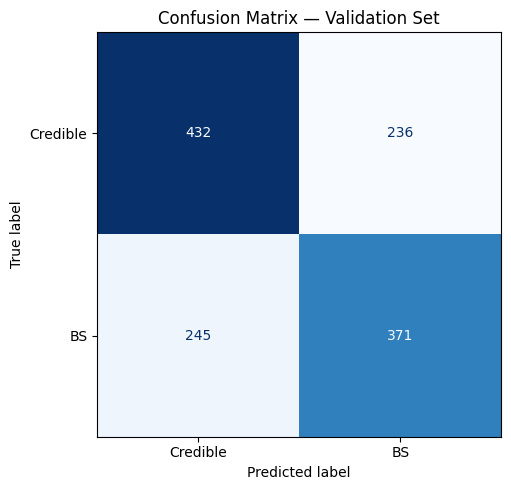

In [26]:
y_pred  = pipeline.predict(X_val)
y_proba = pipeline.predict_proba(X_val)[:, 1]

print("=== Validation Performance ===\n")
print(classification_report(y_val, y_pred,
                             target_names=['Credible (0)', 'BS (1)']))
print(f"ROC-AUC : {roc_auc_score(y_val, y_proba):.4f}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_val, y_pred),
    display_labels=['Credible', 'BS']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## Step 22 — Top Predictive Features

We look at which words pushed the model hardest toward BS and hardest toward credible. This is a sanity check — if random noise is at the top, something is wrong.

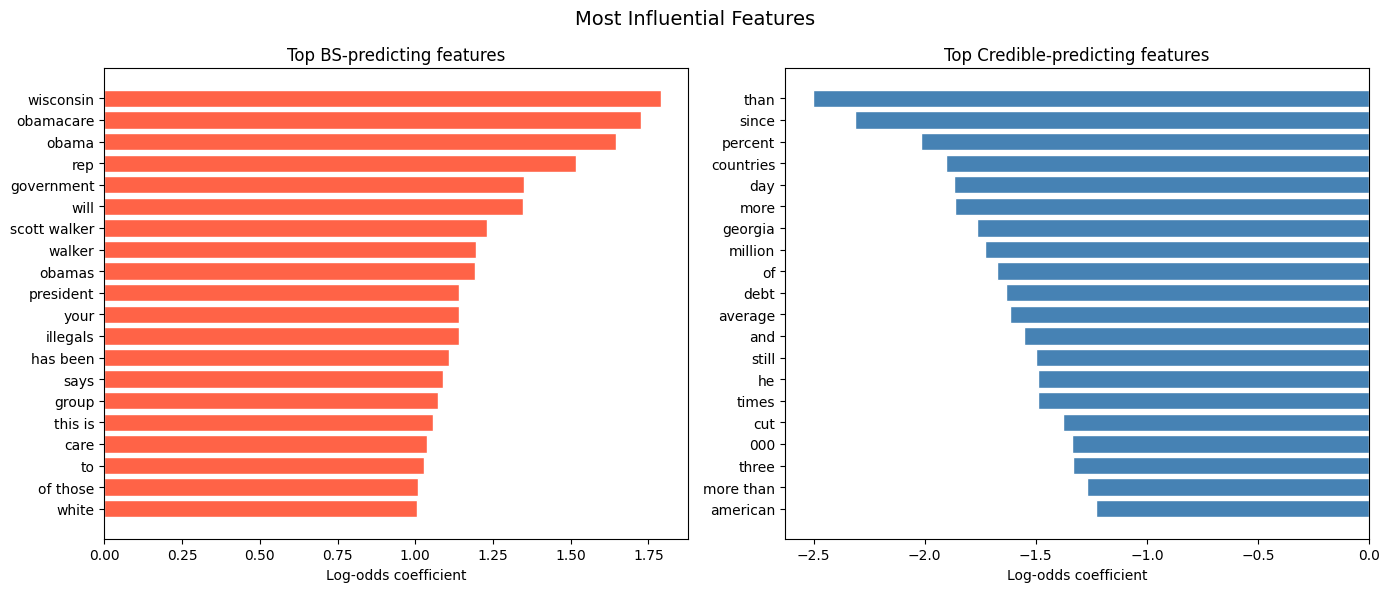

In [27]:
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coefs         = pipeline.named_steps['clf'].coef_[0]

top_n = 20
top_bs_idx   = coefs.argsort()[-top_n:][::-1]
top_cred_idx = coefs.argsort()[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, idx, title, color in zip(
    axes,
    [top_bs_idx, top_cred_idx],
    ['Top BS-predicting features', 'Top Credible-predicting features'],
    ['tomato', 'steelblue']
):
    words  = [feature_names[i] for i in idx]
    scores = [coefs[i] for i in idx]
    ax.barh(words[::-1], scores[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Log-odds coefficient')

plt.suptitle('Most Influential Features', fontsize=14)
plt.tight_layout()
plt.show()

## Step 23 — Final Evaluation on Test Set

We touch the test set exactly once, right here. This is the honest score — the model has never seen this data in any form.

In [28]:
y_test_pred  = pipeline.predict(X_test)
y_test_proba = pipeline.predict_proba(X_test)[:, 1]

print("=== TEST SET — Final Honest Score ===\n")
print(classification_report(y_test, y_test_pred,
                             target_names=['Credible (0)', 'BS (1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_test_proba):.4f}")

=== TEST SET — Final Honest Score ===

              precision    recall  f1-score   support

Credible (0)       0.69      0.67      0.68       714
      BS (1)       0.59      0.60      0.60       553

    accuracy                           0.64      1267
   macro avg       0.64      0.64      0.64      1267
weighted avg       0.64      0.64      0.64      1267

ROC-AUC : 0.6754


## Step 24 — Hyperparameter Tuning

Our baseline scored 64% accuracy and 0.675 ROC-AUC. We try four variations to see if we can do better before saving the final model.

In [30]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

configs = {
    'LogReg C=0.1': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=50_000, sublinear_tf=True, min_df=2)),
        ('clf',   LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000))
    ]),
    'LogReg C=1.0 (baseline)': pipeline,  # our existing trained pipeline
    'LogReg C=10': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=50_000, sublinear_tf=True, min_df=2)),
        ('clf',   LogisticRegression(C=10, class_weight='balanced', max_iter=1000))
    ]),
    'LogReg C=1.0 100k vocab': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=100_000, sublinear_tf=True, min_df=2)),
        ('clf',   LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000))
    ]),
    'LinearSVC C=1.0': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=50_000, sublinear_tf=True, min_df=2)),
        ('clf',   CalibratedClassifierCV(LinearSVC(C=1.0, class_weight='balanced', max_iter=2000)))
    ]),
}

results = {}

for name, pipe in configs.items():
    if name != 'LogReg C=1.0 (baseline)':  # baseline already trained
        pipe.fit(X_train, y_train)

    y_p     = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:, 1]
    auc     = roc_auc_score(y_val, y_proba)
    acc     = (y_p == y_val).mean()
    results[name] = {'Accuracy': round(acc, 4), 'ROC-AUC': round(auc, 4)}
    print(f"{name:<35} Accuracy: {acc:.4f}   ROC-AUC: {auc:.4f}")

LogReg C=0.1                        Accuracy: 0.6254   ROC-AUC: 0.6782
LogReg C=1.0 (baseline)             Accuracy: 0.6254   ROC-AUC: 0.6761
LogReg C=10                         Accuracy: 0.6075   ROC-AUC: 0.6511
LogReg C=1.0 100k vocab             Accuracy: 0.6254   ROC-AUC: 0.6761
LinearSVC C=1.0                     Accuracy: 0.6114   ROC-AUC: 0.6522


## Step 25 — Select the Best Model

We pick whichever config scored highest on ROC-AUC and use that as our final pipeline going into Phase 4.

In [31]:
best_name = max(results, key=lambda x: results[x]['ROC-AUC'])
best_pipeline = configs[best_name]

print(f"Best model  : {best_name}")
print(f"Accuracy    : {results[best_name]['Accuracy']}")
print(f"ROC-AUC     : {results[best_name]['ROC-AUC']}")
print(f"\nThis replaces 'pipeline' as the model we save and use in Phase 4.")

# Overwrite so Step 26 (save) picks up the best one automatically
pipeline = best_pipeline

Best model  : LogReg C=0.1
Accuracy    : 0.6254
ROC-AUC     : 0.6782

This replaces 'pipeline' as the model we save and use in Phase 4.


## Step 26 — Save the Model

We save the entire pipeline — vectoriser and model together — as a single `.pkl` file. Phase 4 loads this one file and immediately has everything it needs to score new statements.

In [33]:
os.makedirs('/content/model', exist_ok=True)
joblib.dump(pipeline, '/content/model/tinfoil_pipeline.pkl')

size_kb = os.path.getsize('/content/model/tinfoil_pipeline.pkl') / 1024
print(f"Model saved → /content/model/tinfoil_pipeline.pkl")
print(f"File size   : {size_kb:.1f} KB")

Model saved → /content/model/tinfoil_pipeline.pkl
File size   : 1200.1 KB


## Phase 3 Complete ✓

- Built a TF-IDF + Logistic Regression pipeline
- Trained on 10,240 statements
- Evaluated on validation, then test (once, at the end)
- Saved pipeline to `/content/model/tinfoil_pipeline.pkl`

**Next — Phase 4: Streamlit App.** We load the saved model and build the actual tinfoil hat rater.